#Assignment 2: Bayesian Inference and the MNIST Dataset
##Author : Poorvi Raut

### Importing necessary python libraries

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the csv files



In [154]:
train_data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Poorvi_Raut_DS_Assignment_2/MNIST_train.csv')
test_data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Poorvi_Raut_DS_Assignment_2/MNIST_test.csv - MNIST_test.csv.csv')

In [155]:
train_data


,Unnamed: 0,index,labels,0,1,2,3,4,5,6,...,774,775,776,777,778,779,780,781,782,783
0,0,0,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,2,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,3,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,4,9,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,59995,59995,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,59996,59996,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,59997,59997,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,59998,59998,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [156]:
test_data

,Unnamed: 0,index,labels,0,1,2,3,4,5,6,...,774,775,776,777,778,779,780,781,782,783
0,0,0,7,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,2,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,4,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,9995,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,9996,9996,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,9997,9997,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,9998,9998,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Displaying basic dataset Information

In [157]:
# Ensure the dataset contains 785 columns: one for labels and 784 for pixel values
#if train_data.shape[1] != 785:
    #raise ValueError("Dataset must contain 785 columns: 'label' + 784 pixel values.")

In [158]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 787 entries, Unnamed: 0 to 783
dtypes: int64(787)
memory usage: 360.3 MB


In [159]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 787 entries, Unnamed: 0 to 783
dtypes: int64(787)
memory usage: 60.0 MB


In [211]:
train_data.describe()

,labels,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


In [212]:
test_data.describe()

,labels,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
count,10000.000000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,...,10000.000000,10000.000000,10000.000000,10000.0000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,4.443400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.179300,0.163600,0.052600,0.0006,0.0,0.0,0.0,0.0,0.0,0.0
std,2.895865,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.674149,5.736072,2.420004,0.0600,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,253.000000,156.000000,6.0000,0.0,0.0,0.0,0.0,0.0,0.0


In [160]:
train_data.shape

(60000, 787)

In [161]:
test_data.shape

(10000, 787)

In [162]:
train_data.drop(train_data.columns[[0, 1]], axis=1, inplace=True)

In [163]:
train_data

,labels,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [164]:
test_data.drop(test_data.columns[[0, 1]], axis=1, inplace=True)

In [165]:
test_data

,labels,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [166]:
# Handling missing values
print("Missing values:", train_data.isnull().sum().sum())

Missing values: 0


###Data Preparation

In [167]:
train_data.head()

,labels,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [168]:
#train_data.drop(["Unnamed: 0","index"],axis=1,inplace=True)

In [169]:
#test_data.drop(["Unnamed: 0","index"],axis=1,inplace=True)

In [170]:
X=train_data.drop("labels",axis=1)
y=train_data["labels"]

In [171]:
X_test=test_data.drop("labels",axis=1)
y_test=test_data["labels"]

In [172]:
# Normalize pixel values (0-255 -> 0-1)
#X = X /255.0

In [173]:
X.shape

(60000, 784)

In [174]:
y.shape

(60000,)

In [175]:
X_test.shape

(10000, 784)

In [176]:
y_test.shape

(10000,)

In [177]:
#X = X[:, :784]  # Keep only the first 784 columns

In [178]:
#Train-test split (70% train, 30% validation)
#split_idx = int(0.7 * len(X))
#X_train, X_test = X[:split_idx], X[split_idx:]
#y_train, y_test = y[:split_idx], y[split_idx:]


In [179]:
#print(f"Training Data Shape: {X_train.shape},Testing Data Shape: {X_test.shape}")

### EDA and Data Visualization

In [180]:
# Reshape pixel data into 28x28 images for visualization (only for plotting purposes)
images = X.values.reshape(-1, 28, 28)

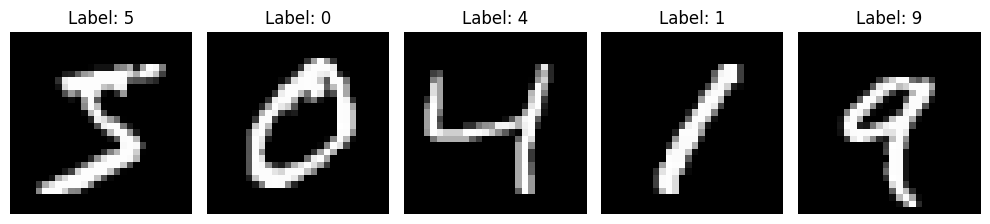

In [181]:
plt.figure(figsize=(10,5))
for i in range(5):  # Displaying first 5 samples
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')  # Use reshaped images for visualization
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [206]:
X_image=np.array(X)[50]

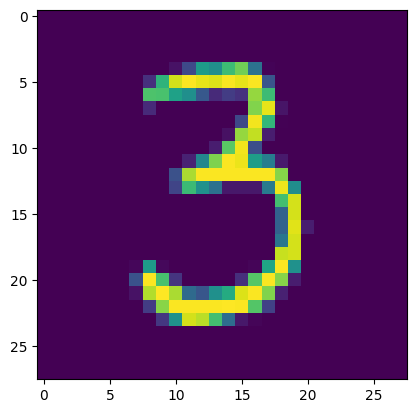

In [207]:
plt.imshow(X_image.reshape(28,28))

In [208]:
def show_me(X):
  plt.imshow(X.reshape(28,28))

def show_me_all_mean(X,y,k):
  show_me(sum(X.loc[y==k, :].values/len(X.loc[y==k,:])))

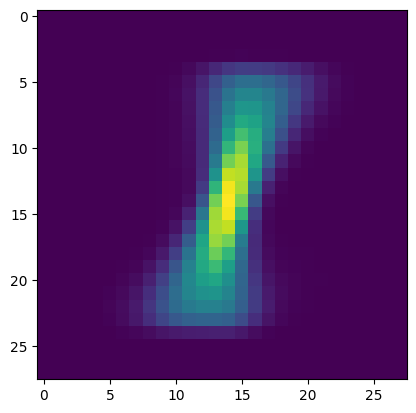

In [209]:
show_me_all_mean(X,y,1)

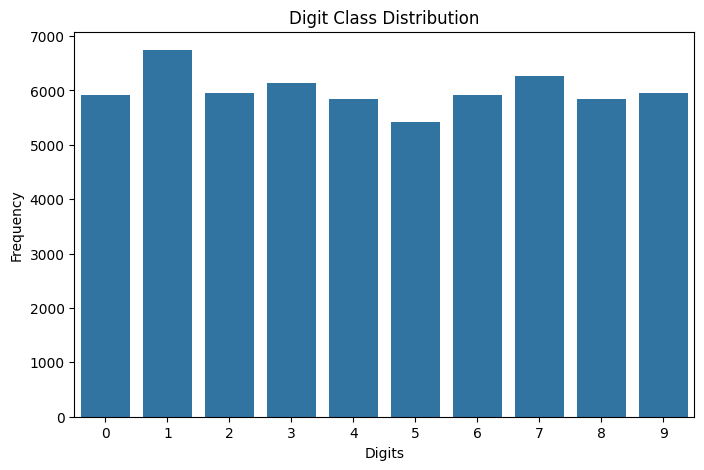

In [186]:
plt.figure(figsize=(8,5))
sns.countplot(x=y)
plt.title('Digit Class Distribution')
plt.xlabel('Digits')
plt.ylabel('Frequency')
plt.show()

### Naive Bayes  Classifier

In [187]:
from scipy.stats import multivariate_normal as mvn

In [188]:
class GaussNB():
  def fit(self,X,y,epsilon=1e-3):
    self.likelihoods=dict()
    self.priors=dict()#prior for each class
    self.K=set(y.astype(int))#for classification of unique values object 0 and 9
    for k in self.K:
      X_k=X[y==k]
      self.priors[k]=len(X_k)/len(X)
      self.likelihoods[k]=dict()
      for x in X.columns:
        self.likelihoods[k][x]={"mean":X_k[x].mean(axis=0),"sd":X_k[x].std(axis=0) + epsilon}

  def predict(self,X):
    N,D=X.shape
    P_hat=np.zeros((N,len(self.K)))

    for i,k in enumerate(self.K):
      log_add=np.log(self.priors[k])
      for x in X.columns:
        mean,sd=self.likelihoods[k][x]["mean"],self.likelihoods[k][x]["sd"]
        log_add+=mvn.logpdf(X[x],mean,sd)
      P_hat[:,k]=log_add
    return P_hat.argmax(axis=1)


In [189]:
def accuracy(y,y_hat):
  return np.mean(y==y_hat)

In [190]:
gnb=GaussNB()

In [191]:
gnb.fit(X,y)

In [192]:
y_hat=gnb.predict(X)

In [193]:
# for training data
accuracy(y,y_hat)

np.float64(0.8439)

In [194]:
# for testing data
y_hat_test=gnb.predict(X_test)
accuracy(y_test,y_hat_test)

np.float64(0.8484)

Text(0.5, 47.7222222222222, 'Predicted label')

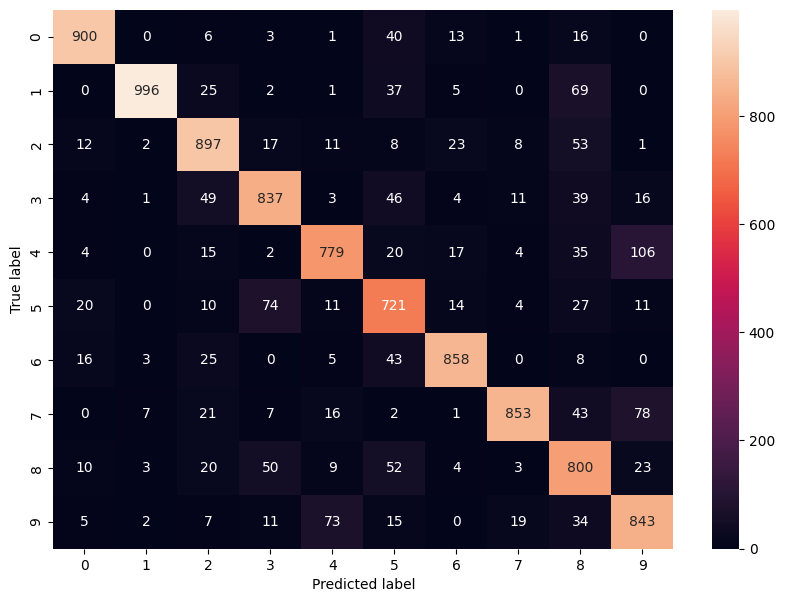

In [195]:
# confusion matrix for testing data
plt.figure(figsize=(10,7))
y_actu = pd.Series(y_test, name='Actual')
y_pred = pd.Series(y_hat_test, name='Predicted')
cm = pd.crosstab(y_actu, y_pred)
ax = sns.heatmap(cm, annot=True, fmt="d")
plt.ylabel('True label')
plt.xlabel('Predicted label')

### Non- Naive Gauss Bayes Classifier

In [196]:
class NonGaussBayes():
    def fit(self, X, y, epsilon=1e-2): #changing the value of epsilon
        self.likelihoods = dict()
        self.priors = dict()
        self.K = set(y.astype(int))

        for k in self.K:
            # Use .loc for label-based indexing
            X_k = X.loc[y == k, :]
            N_k, D = X_k.shape
            mu_k = X_k.mean(axis=0)

            self.likelihoods[k] = {"mean": X_k.mean(axis=0), "cov": (1 / (N_k - 1)) * np.matmul((X_k - mu_k).T, X_k - mu_k) + epsilon * np.identity(D)}
            self.priors[k] = len(X_k) / len(X)

    def predict(self, X):
        N, D = X.shape
        P_hat = np.zeros((N, len(self.K)))
        for k, l in self.likelihoods.items():
            P_hat[:, k] = mvn.logpdf(X, l["mean"], l["cov"]) + np.log(self.priors[k])
        return P_hat.argmax(axis=1)

In [197]:
gaussb=NonGaussBayes()
#gaussb.likelihoods

In [198]:
gaussb.fit(X,y)
y_hat2=gaussb.predict(X)
accuracy(y_hat2,y)

np.float64(0.81035)

In [199]:
#y_hat2=gaussb.predict(X)

In [200]:
#accuracy(y_hat2,y)

In [201]:
#on testing data
y_hat_test2=gaussb.predict(X_test)
accuracy(y_test,y_hat_test2)

np.float64(0.7809)

In [202]:
#Normalization of features
X=X/255
X_test=X_test/255

In [203]:
# again training the Non-naive bayes model after normalization and finding accuracy of training set
gaussb.fit(X,y)
y_hat2=gaussb.predict(X)
accuracy(y_hat2,y)

np.float64(0.9555333333333333)

In [204]:
# Non-naive bayes for testing data
y_hat_test2=gaussb.predict(X_test)
accuracy(y_test,y_hat_test2)

np.float64(0.9473)

Text(0.5, 47.7222222222222, 'Predicted label')

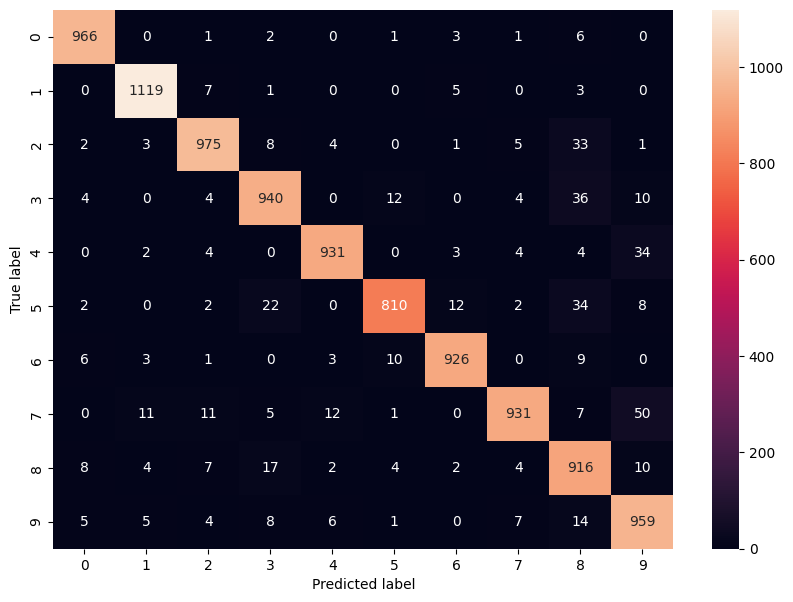

In [205]:
#plotting the confusion matrix for testing data
plt.figure(figsize=(10,7))
y_actu = pd.Series(y_test, name='Actual')
y_pred = pd.Series(y_hat_test2, name='Predicted')
cm = pd.crosstab(y_actu, y_pred)
ax = sns.heatmap(cm, annot=True, fmt="d")
plt.ylabel('True label')
plt.xlabel('Predicted label')